In [2]:
import typing, importlib, numpy as np, jax, jax.numpy as jnp, matplotlib.pyplot as plt

In [3]:
import metanet
importlib.reload(metanet)

<module 'metanet' from '/home/pesim/uni/thesis/metanet.py'>

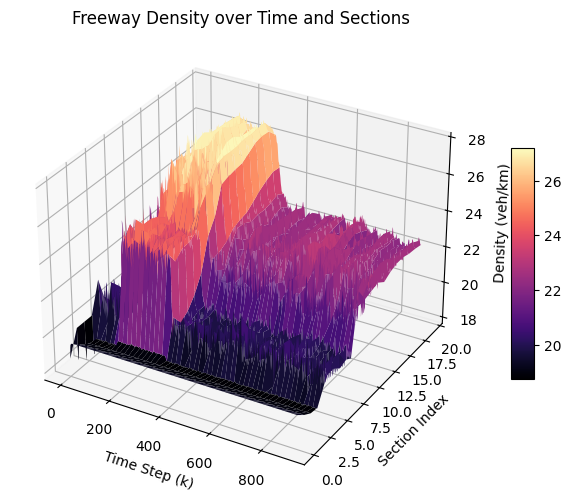

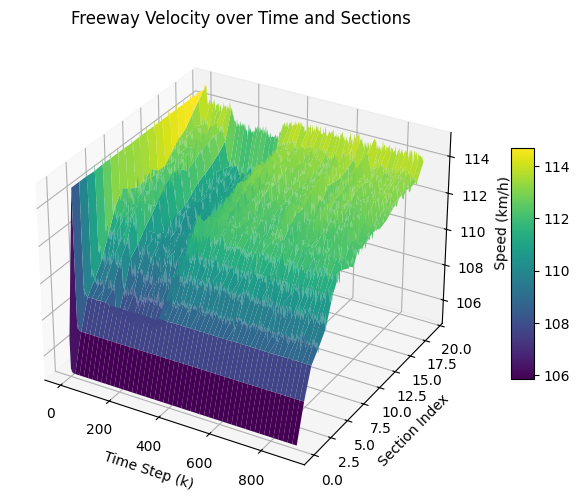

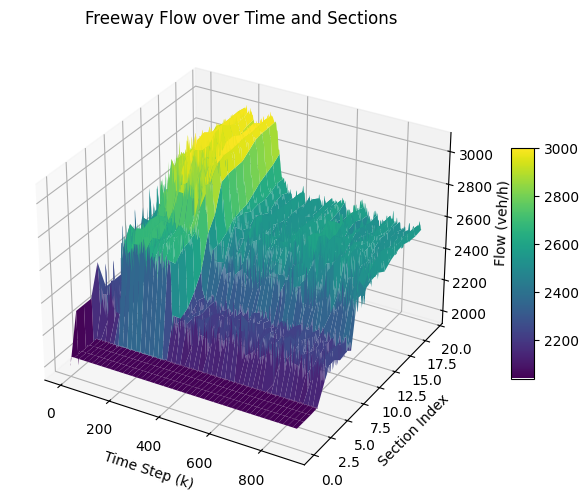

In [4]:
import numpy as np
N = 20
K = 360 * 2 + 180  # 900 steps
T = 10.0 / 3600.0  # 10 seconds in hours

L = np.full(N, 0.5)
lambda_ = np.full(N, 1.0)

vf = np.full(N, 120.0)

# Exponential Fundamental Diagram Parameters (Standard METANET)
rho_cr = np.full(N, 80.0)
alpha = np.full(N, 1.8)

tau = np.full(N, 0.02)

# Standard METANET defaults for momentum parameters
nu = np.full(N, 60.0)     
kappa = np.full(N, 40.0)  
delta = np.full(N, 0.012) 

params = metanet.NetworkParameters(
T=T, L=jnp.array(L), lambda_=jnp.array(lambda_),
tau=jnp.array(tau), nu=jnp.array(nu), kappa=jnp.array(kappa), delta=jnp.array(delta),
alpha=jnp.array(alpha), critical_density=jnp.array(rho_cr), free_flow_speed=jnp.array(vf)
)

# ---------------------------
# Setup Demand Profile
# ---------------------------
dem = np.zeros((K, N))
key = jax.random.PRNGKey(0)
subkey, key = jax.random.split(key)
dem[:, 4] = 200 + 100 * jax.random.normal(subkey, (K,)) 
subkey, key = jax.random.split(key)
dem[:, 9] = 200 + 100 * jax.random.normal(subkey, (K,))  
subkey, key = jax.random.split(key)
dem[:, 11] = 100 + 50 * jax.random.normal(subkey, (K,))  # Add faster oscillation to demand at section 12
# Rush-hour pulse (k=100 to 300, mapped to Python 99 to 300)


subkey, key = jax.random.split(key)
dem[99:300, 4] = 600 + 100 * jax.random.normal(subkey, (300-99,)) 
subkey, key = jax.random.split(key)
dem[99:300, 9] = 200 + 100 * jax.random.normal(subkey, (300-99,)) 
subkey, key = jax.random.split(key)
dem[99:300, 11] = 100 + 50 * jax.random.normal(subkey, (300-99,))


s_off = np.zeros((K, N))

# ---------------------------
# Setup Initial & Boundary Values
# ---------------------------
rho_init = np.full(N, 20.0)
v_init = vf * np.exp(-(1.0 / alpha) * (rho_init / rho_cr)**alpha)
q_init = rho_init * v_init * lambda_
queue_init = np.zeros(N)

init_state = metanet.NetworkState(
    density=jnp.array(rho_init), 
    flow=jnp.array(q_init), 
    speed=jnp.array(v_init), 
)

rho0_val = 20.0
v0_val = 120.0 * np.exp(- (1.0 / 1.8) * (rho0_val / 40.0)**1.8)

boundaries = metanet.BoundarySequence(
    q_0=jnp.full(K, rho0_val * v0_val),
    v_0=jnp.full(K, v0_val),
    rho_N_plus_1=jnp.full(K, rho_init[-1]), # Maintain free boundary
    r=jnp.array(dem),
    s=jnp.zeros((K, N))
)

# ---------------------------
# Run Simulation
# ---------------------------
traj = metanet.rollout_simulation(init_state, boundaries, params)

# Block until execution finishes
density_res = np.array(traj.density)
speed_res = np.array(traj.speed)
flow_res = np.array(traj.flow)

# ---------------------------
# Plot 3D Surfaces
# ---------------------------
time_grid, section_grid = np.meshgrid(np.arange(K), np.arange(N))

# 1. Density Plot
fig1 = plt.figure(figsize=(10, 6))
ax1 = fig1.add_subplot(111, projection='3d')
# Transpose data to match meshgrid (Sections x Time)
surf1 = ax1.plot_surface(time_grid, section_grid, density_res.T, cmap='magma', edgecolor='none')
ax1.set_title('Freeway Density over Time and Sections')
ax1.set_xlabel('Time Step (k)')
ax1.set_ylabel('Section Index')
ax1.set_zlabel('Density (veh/km)')
fig1.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)

# 2. Velocity Plot
fig2 = plt.figure(figsize=(10, 6))
ax2 = fig2.add_subplot(111, projection='3d')
surf2 = ax2.plot_surface(time_grid, section_grid, speed_res.T, cmap='viridis', edgecolor='none')
ax2.set_title('Freeway Velocity over Time and Sections')
ax2.set_xlabel('Time Step (k)')
ax2.set_ylabel('Section Index')
ax2.set_zlabel('Speed (km/h)')
fig2.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)

fig3 = plt.figure(figsize=(10, 6))
ax3 = fig3.add_subplot(111, projection='3d')
surf3 = ax3.plot_surface(time_grid, section_grid, flow_res.T, cmap='viridis', edgecolor='none')
ax3.set_title('Freeway Flow over Time and Sections')
ax3.set_xlabel('Time Step (k)')
ax3.set_ylabel('Section Index')
ax3.set_zlabel('Flow (veh/h)')
fig3.colorbar(surf3, ax=ax3, shrink=0.5, aspect=10)

plt.show()



In [5]:
import plotly.graph_objects as go

# 1. Interactive Density Plot
fig1 = go.Figure(data=[go.Surface(
    z=density_res.T,  # Transpose as per your original code logic
    x=time_grid, 
    y=section_grid, 
    colorscale='Magma'
)])

fig1.update_layout(
    title='Freeway Density over Time and Sections',
    scene=dict(
        xaxis_title='Time Step (k)',
        yaxis_title='Section Index',
        zaxis_title='Density (veh/km)'
    ),
    width=800, height=700
)
fig1.show()

# 2. Interactive Velocity Plot
fig2 = go.Figure(data=[go.Surface(
    z=speed_res.T, 
    x=time_grid, 
    y=section_grid, 
    colorscale='Viridis'
)])

fig2.update_layout(
    title='Freeway Velocity over Time and Sections',
    scene=dict(
        xaxis_title='Time Step (k)',
        yaxis_title='Section Index',
        zaxis_title='Speed (km/h)'
    ),
    width=800, height=700
)
fig2.show()

# 3. Interactive Flow Plot
fig3 = go.Figure(data=[go.Surface(
    z=flow_res.T, 
    x=time_grid, 
    y=section_grid, 
    colorscale='Viridis'
)])

fig3.update_layout(
    title='Freeway Flow over Time and Sections',
    scene=dict(
        xaxis_title='Time Step (k)',
        yaxis_title='Section Index',
        zaxis_title='Flow (veh/h)'
    ),
    width=800, height=700
)
fig3.show()